In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from scipy import stats

# Load Dataset
data = load_diabetes(as_frame=True)
df = data.frame

print("Dataset Snapshot:")
display(df.head())

print("\nStatistical Summary of All Features:")
display(df.describe(include='all'))




Dataset Snapshot:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



Statistical Summary of All Features:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


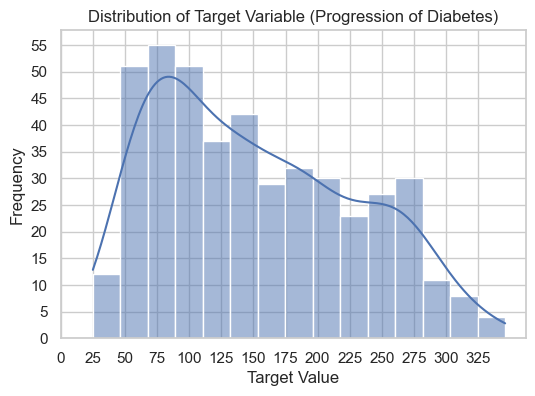

In [17]:
plt.figure(figsize=(6, 4))
sns.histplot(df['target'], kde=True, bins=15)
plt.xticks(ticks=range(0, 350, 25)) 
plt.yticks(ticks=range(0, 60, 5)) 
plt.title("Distribution of Target Variable (Progression of Diabetes)")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

The Histogram above shows the most common values lie around 50-100 (75)
The distribution could maybe be bimodal? Although the peak(s) around 275 (and maybe even 200) might not be significant enough to substansiate that claim

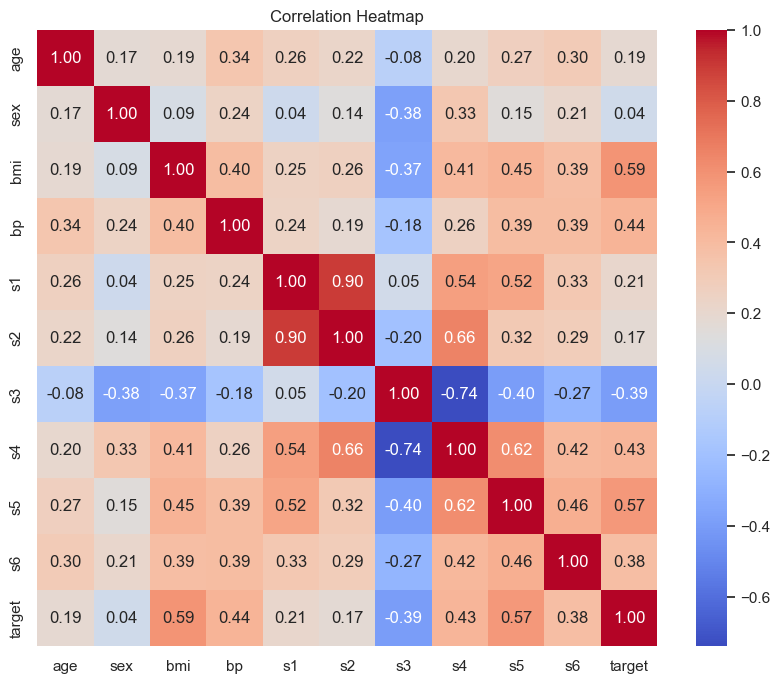

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap above shows extremely high correlation in the following areas:

An extremely strong positive correlation between s1 and s2 = 0.90 (Total Serum Cholesterol and Low-Density Lipoproteins)

A very strong negative correlation between s3 and s4 = -0.74 (High Density Lipoproteins and Total Cholesterol/LDL)

s4 seems to have somewhat decent positive correlations across the axis until it gets to s3, where the opposite is true

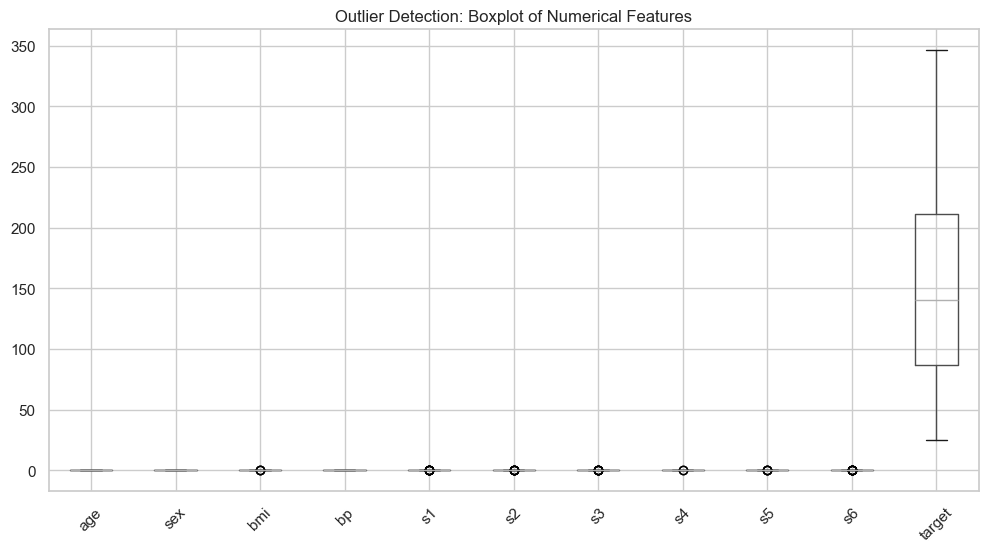

In [ ]:
# Outlier Detection using Boxplot for Numerical Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title("Outlier Detection: Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

# INdividual plots for further validation
# numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# num_features = len(numeric_cols)

# plt.figure(figsize=(5, num_features * 3))
# for i, col in enumerate(numeric_cols, 1):
#     plt.subplot(num_features, 1, i)
#     df.boxplot(column=col)
#     plt.title(f"Boxplot of {col}")
#     plt.tight_layout()
# plt.show()

In [11]:
# Identify Outliers with Z-Score
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))
outliers = (z_scores > 3)
outlier_counts = pd.Series(outliers.sum(axis=0), index=numeric_cols)
print("\nOutlier Count Per Feature (Z-Score > 3):")
print(outlier_counts)

# Missing Value Analysis
missing_counts = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent (%)': missing_percent
})
print("\nMissing Value Analysis:")
display(missing_df[missing_df['Missing Count'] > 0])


Outlier Count Per Feature (Z-Score > 3):
age       0
sex       0
bmi       2
bp        0
s1        2
s2        2
s3        5
s4        4
s5        0
s6        0
target    0
dtype: int64

Missing Value Analysis:


,Missing Count,Missing Percent (%)
